# Isotropic Bias Diagnostics

This notebook visualises the three main factors that cause the observer-recovered
isotropic energy $E_{\rm iso,rec}$ to differ from the intrinsic model value
$E_{\rm iso,true}$:

| Quantity | Symbol | Role |
|----------|--------|------|
| k-correction | $k_{\rm corr}$ | Band redshift correction |
| Bolometric correction | $\mathcal{B}$ | Energy outside detector band |
| Viewing-angle suppression | $R_F(\theta_v)$ | Off-axis flux dimming |

See `Paper_Notebooks/isotropic_quantities_bias.md` for the analytical derivation.

In [1]:
%load_ext autoreload
%autoreload 2
import notebook_setup

import numpy             as np
import matplotlib.pyplot as plt
import matplotlib        as mpl
from   pathlib           import Path

from src                import init
from src.montecarlo     import compute_iso_bias_diagnostics

plt.style.use('../configurations/style.mplstyle')
datafiles = Path('../datafiles')

## Initialise simulation

Uses the same `initialize_simulation` call as the analysis notebooks.

In [2]:
jet_params = {
    "alpha"       : -0.67,
    "beta_s"      : -2.59,
    "n"           : 2,
    "theta_c"     : 3.4,
    "theta_v_max" : 10,
    "z_model"     : None,   # set to e.g. 'fiducial_Hrad_A1.0' to use MRD
}

params, interps, data_dict = init.initialize_simulation(
    datafiles = datafiles,
    params    = jet_params,
    size_test = 5_000
)

Using default redshift distribution: Catalog_co_BNSs_a_3.0_sn_delayed.txt
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year


## Set model parameters (thetas)

`thetas = [k_pl, L_L0, log10(E_p), sigma_E_p, log10(t_peak), sigma_t_peak, f_j]`

Edit the cell below to match the posterior values you want to inspect.

In [ ]:
# ── posterior / fiducial parameter vector ─────────────────────────────────────
#   [k_pl,   L_L0,  log10(Ep),  sigma_Ep,  log10(tp),  sigma_tp,  f_j]
thetas = [1.5,   50.5,    2.4,        0.35,      -1.5,       0.35,      0.1]

# Number of MC draws (increase for smoother distributions)
N_MC = 500

diag = compute_iso_bias_diagnostics(
    thetas   = thetas,
    params   = params,
    interps  = interps,
    n_events = N_MC,
)

if diag is None:
    raise RuntimeError("No events survived detection cuts – try different thetas or increase N_MC.")

print(f"Detected events : {len(diag['k_corr'])}")
print(f"k_corr          : median={np.median(diag['k_corr']):.3f}, "
      f"IQR=[{np.percentile(diag['k_corr'],25):.3f}, {np.percentile(diag['k_corr'],75):.3f}]")
print(f"bolo_correction : median={np.median(diag['bolo_correction']):.2f}")
print(f"E_iso ratio     : median={np.median(diag['ratio']):.3f}")

Detected events : 8627
k_corr          : median=2.825, IQR=[1.835, 4.193]
bolo_correction : median=15.09
E_iso ratio     : median=1.369


## Figure 1 – Histograms of the correction factors

Side-by-side comparison of $k_{\rm corr}$ (band redshift correction) and the
bolometric correction factor $\mathcal{B} = \int_1^{10^4}\!EN\,dE \;/\;
\int_{50}^{300}\!EN\,dE$  (rest-frame over BATSE band), together with the
resulting $E_{\rm iso,rec}/E_{\rm iso,true}$ ratio.

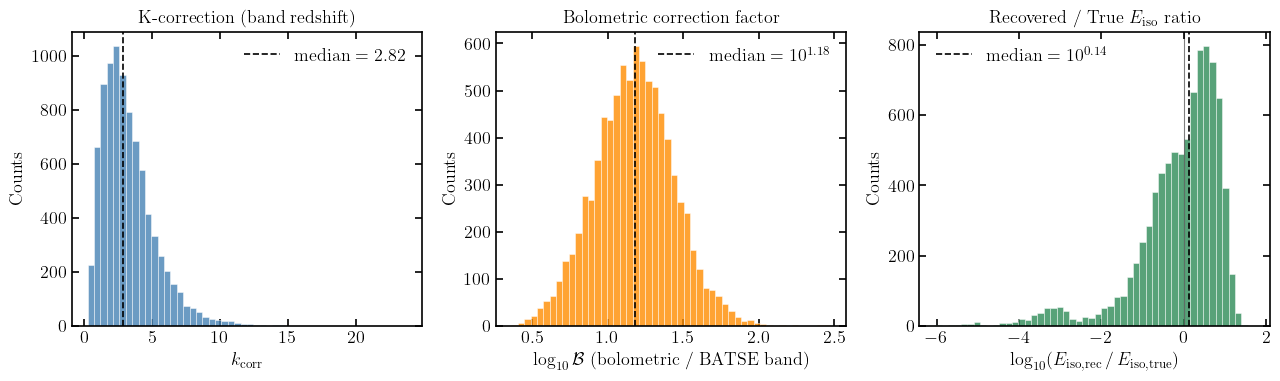

In [4]:
N_BINS = 50

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

ax_k, ax_b, ax_r = axes

# --- k-correction -------------------------------------------------------
ax_k.hist(diag['k_corr'], bins=N_BINS, color='steelblue', alpha=0.8,
          edgecolor='white', linewidth=0.4)
ax_k.axvline(np.median(diag['k_corr']), color='k', ls='--', lw=1.2,
             label=fr"median $= {np.median(diag['k_corr']):.2f}$")
ax_k.set_xlabel(r'$k_{\rm corr}$')
ax_k.set_ylabel('Counts')
ax_k.set_title(r'K-correction (band redshift)')
ax_k.legend(frameon=False)

# --- bolometric correction -----------------------------------------------
log_bc = np.log10(diag['bolo_correction'])
ax_b.hist(log_bc, bins=N_BINS, color='darkorange', alpha=0.8,
          edgecolor='white', linewidth=0.4)
ax_b.axvline(np.median(log_bc), color='k', ls='--', lw=1.2,
             label=fr"median $= 10^{{{np.median(log_bc):.2f}}}$")
ax_b.set_xlabel(r'$\log_{10}\mathcal{B}$  (bolometric / BATSE band)')
ax_b.set_ylabel('Counts')
ax_b.set_title(r'Bolometric correction factor')
ax_b.legend(frameon=False)

# --- E_iso ratio ---------------------------------------------------------
log_r = np.log10(diag['ratio'])
ax_r.hist(log_r, bins=N_BINS, color='seagreen', alpha=0.8,
          edgecolor='white', linewidth=0.4)
ax_r.axvline(0, color='k', ls='-', lw=0.8, alpha=0.5)
ax_r.axvline(np.median(log_r), color='k', ls='--', lw=1.2,
             label=fr"median $= 10^{{{np.median(log_r):.2f}}}$")
ax_r.set_xlabel(r'$\log_{10}(E_{\rm iso,rec}\,/\,E_{\rm iso,true})$')
ax_r.set_ylabel('Counts')
ax_r.set_title(r'Recovered / True  $E_{\rm iso}$ ratio')
ax_r.legend(frameon=False)

fig.tight_layout()
plt.show()

## Figure 2 – Corner plot: $\theta_v$, $k_{\rm corr}$, $\mathcal{B}$, ratio

Lower-triangle 2-D scatter (hexbin) panels and diagonal histograms.
The colour scale encodes point density on the off-diagonal panels.

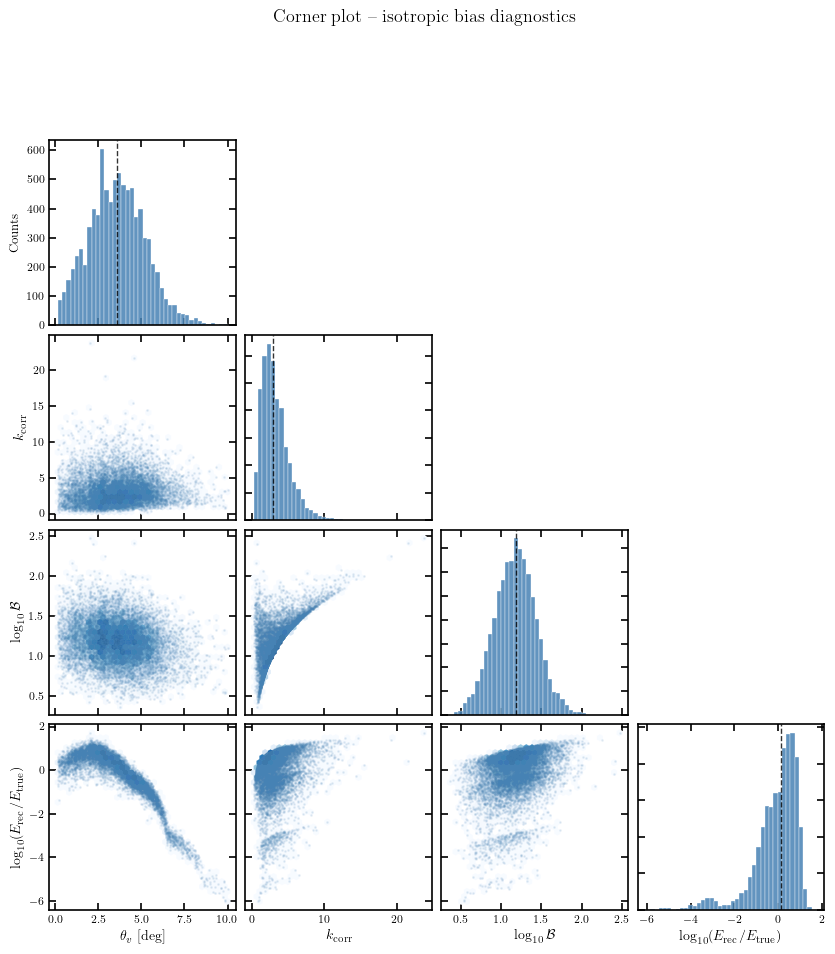

In [5]:
# ── data preparation ──────────────────────────────────────────────────────────
corner_data = {
    r'$\theta_v$ [deg]'                              : diag['theta_v'],
    r'$k_{\rm corr}$'                                : diag['k_corr'],
    r'$\log_{10}\mathcal{B}$'                        : np.log10(diag['bolo_correction']),
    r'$\log_{10}(E_{\rm rec}/E_{\rm true})$'         : np.log10(diag['ratio']),
}

labels = list(corner_data.keys())
arrays = list(corner_data.values())
ndim   = len(labels)

# ── corner layout ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(ndim, ndim, figsize=(10, 10))
fig.subplots_adjust(hspace=0.05, wspace=0.05)

HIST_COLOR   = 'steelblue'
CMAP         = 'Blues'
N_BINS_DIAG  = 40
N_BINS_HEX   = 30

for row in range(ndim):
    for col in range(ndim):
        ax = axes[row, col]

        if col > row:                          # upper triangle – hide
            ax.set_visible(False)
            continue

        if col == row:                         # diagonal – 1-D histogram
            ax.hist(arrays[row], bins=N_BINS_DIAG,
                    color=HIST_COLOR, alpha=0.85,
                    edgecolor='white', linewidth=0.3)
            ax.axvline(np.median(arrays[row]), color='k',
                       ls='--', lw=1.0, alpha=0.8)

        else:                                  # lower triangle – 2-D hexbin
            hb = ax.hexbin(arrays[col], arrays[row],
                           gridsize=N_BINS_HEX,
                           cmap=CMAP, mincnt=1,
                           linewidths=0.2)
            # scatter a thin alpha layer to show low-density regions
            ax.scatter(arrays[col], arrays[row],
                       s=1, alpha=0.10, color='steelblue', rasterized=True)

        # ── axis labels: only outer edges ─────────────────────────────────
        if row == ndim - 1:
            ax.set_xlabel(labels[col], fontsize=10)
        else:
            ax.set_xticklabels([])

        if col == 0:
            if row == 0:
                ax.set_ylabel('Counts', fontsize=9)
            else:
                ax.set_ylabel(labels[row], fontsize=10)
        else:
            ax.set_yticklabels([])

        ax.tick_params(axis='both', which='major', labelsize=8)

fig.suptitle(r'Corner plot – isotropic bias diagnostics', y=1.01, fontsize=13)
plt.show()

## Figure 3 – Viewing-angle slices

Median and 1-$\sigma$ band of $k_{\rm corr}$, $\mathcal{B}$, and the total
ratio as a function of $\theta_v$ to see which effect is angle-dependent.

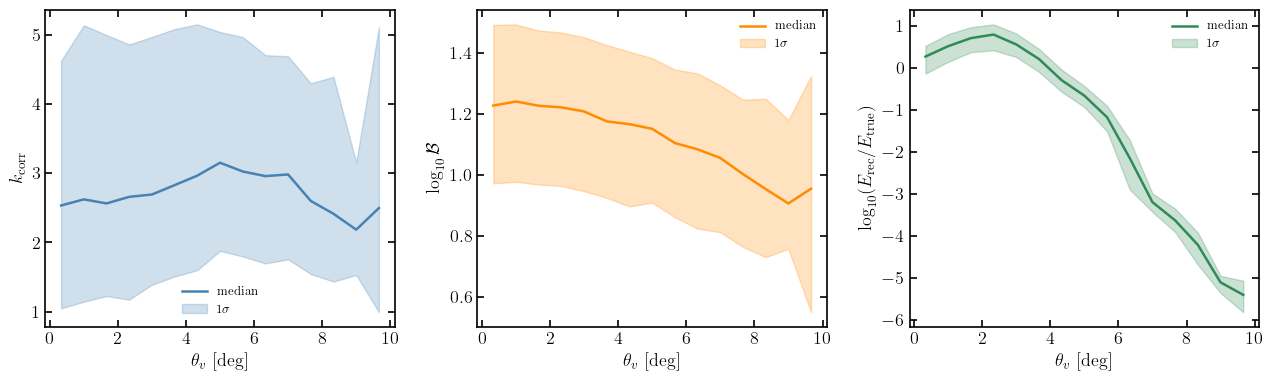

In [6]:
theta_deg   = diag['theta_v']
theta_edges = np.linspace(0, theta_deg.max(), 16)
theta_c     = 0.5 * (theta_edges[:-1] + theta_edges[1:])
idx_bins    = np.digitize(theta_deg, theta_edges) - 1

def bin_stat(arr, idx, n_bins):
    med  = np.full(n_bins, np.nan)
    lo   = np.full(n_bins, np.nan)
    hi   = np.full(n_bins, np.nan)
    for b in range(n_bins):
        mask = idx == b
        if mask.sum() < 3:
            continue
        med[b] = np.median(arr[mask])
        lo[b]  = np.percentile(arr[mask], 16)
        hi[b]  = np.percentile(arr[mask], 84)
    return med, lo, hi

n_bins  = len(theta_c)
quantities = {
    r'$k_{\rm corr}$'                          : diag['k_corr'],
    r'$\log_{10}\mathcal{B}$'                  : np.log10(diag['bolo_correction']),
    r'$\log_{10}(E_{\rm rec}/E_{\rm true})$'   : np.log10(diag['ratio']),
}
colors = ['steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

for ax, (label, arr), color in zip(axes, quantities.items(), colors):
    med, lo, hi = bin_stat(arr, idx_bins, n_bins)
    ax.plot(theta_c, med, color=color, lw=1.8, label='median')
    ax.fill_between(theta_c, lo, hi, color=color, alpha=0.25, label=r'$1\sigma$')
    ax.set_xlabel(r'$\theta_v$ [deg]')
    ax.set_ylabel(label)
    ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
plt.show()